# CCM on SHREC Latent Coordinates vs. SINDy Residuals

**Pipeline position:** This notebook follows `03_SHREC_Latent_Extraction.ipynb`, which produced the latent coordinate ψ₁ from a four-variable SHREC run (anchovy, sardine, SST-Scripps, SST-Newport), and `02_SINDy_Initial_Model.ipynb`, which fitted sparse dynamical equations to the fish populations.  Results here feed directly into `05_SINDy_with_SHREC_Psi.ipynb`.

**What this notebook does:**
1. Load ψ₁ directly from the pre-computed CSV (`shrec_1var_latent_coordinates.csv`).
2. Reconstruct SINDy one-step predictions and compute model residuals.
3. Align all time series to a common calendar window.
4. Run CCM in both directions between ψ₁ and (a) observed fish populations, (b) SINDy residuals.
5. Fit asymptotic convergence models to every CCM curve.

**Research question:**  Does the shared latent driver recovered by SHREC — a coordinate that lives on the joint attractor of all four ecosystem variables — carry causal information that SINDy's sparse, equation-based model failed to capture?

---

**Reference:** Sugihara, G., May, R., Ye, H., Hsieh, C.-H., Deyle, E., Fogarty, M., & Munch, S. (2012).  
Detecting causality in complex ecosystems. *Science*, 338(6106), 496–500.  
DOI: [10.1126/science.1227079](https://doi.org/10.1126/science.1227079)

> **Why anchovy × sardine for SHREC?**  
> SINDy was given *anchovy* and *sardine* (plus SST) and discovered equations that couple
> the two fish populations.  The ψ we feed into CCM must represent the shared dynamical
> structure of *those same two variables* — otherwise we would be importing causal
> information from a different manifold.  Running SHREC on anchovy + sardine gives us
> the latent coordinate that lives inside their joint attractor, which is exactly what
> we want to test against SINDy's residuals.


## Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

## Helper Functions

In [5]:
def embed(ts, E, tau=1):
    """Time-delay embedding of a 1-D time series (Takens, 1981)."""
    ts = np.array(ts)
    N  = len(ts)
    embedded = np.full((N, E), np.nan)
    for i in range(E):
        shift = i * tau
        if shift == 0:
            embedded[:, i] = ts
        else:
            embedded[shift:, i] = ts[:-shift]
    return embedded


def ccm_smooth(X_raw, Y_raw, E, tau=1, L_range=None, num_samples=50):
    """
    Convergent Cross Mapping skill ρ(L) — cross-map from the shadow manifold
    of X to reconstruct Y, averaged over `num_samples` random library draws.
    """
    np.random.seed(42)
    X_raw, Y_raw = np.array(X_raw), np.array(Y_raw)
    X_emb  = embed(X_raw, E, tau)
    valid  = np.where(~np.isnan(X_emb).any(axis=1) & ~np.isnan(Y_raw))[0]

    rho_results = []
    for L in L_range:
        rho_L = []
        for _ in range(num_samples):
            lib_idx = np.random.choice(valid, size=L, replace=False)
            tree    = cKDTree(X_emb[lib_idx])
            dists, inds = tree.query(X_emb[valid], k=E + 2)

            y_preds, y_actuals = [], []
            for i, t in enumerate(valid):
                mask = (lib_idx[inds[i]] != t)
                nn_idx   = inds[i][mask][:E + 1]
                nn_dists = dists[i][mask][:E + 1]
                if len(nn_idx) < E + 1:
                    continue
                d1 = nn_dists[0]
                w  = (nn_dists == 0).astype(float) if d1 == 0 else np.exp(-nn_dists / d1)
                w /= w.sum()
                y_preds.append(np.dot(w, Y_raw[lib_idx[nn_idx]]))
                y_actuals.append(Y_raw[t])

            if len(y_preds) > 1:
                rho_L.append(pearsonr(y_preds, y_actuals)[0])
            else:
                rho_L.append(np.nan)

        rho_results.append(np.nanmean(rho_L))

    return np.array(L_range), np.maximum(0, rho_results)


def convergence_model(L, alpha, gamma, rho_inf):
    """Exponential convergence model: ρ(L) = α · exp(−γL) + ρ∞."""
    return alpha * np.exp(-gamma * L) + rho_inf


def fit_convergence(L_range, rho_data, label, ax=None, color='steelblue'):
    """
    Fit ρ(L) = α·exp(−γL) + ρ∞ and report the asymptotic cross-map skill ρ∞.
    Plots the fit curve on `ax` when provided.
    """
    rho_data = np.asarray(rho_data)
    finite   = np.isfinite(rho_data)
    if finite.sum() < 4:
        print(f"  {label:55} | ⚠ too few finite points")
        return None
    Lf, rf = L_range[finite].astype(float), rho_data[finite]
    try:
        p0     = [rf.min() - rf.max(), 0.05, rf.max()]
        bounds = ([-np.inf, 0, 0], [np.inf, np.inf, 1.0])
        popt, _ = curve_fit(convergence_model, Lf, rf,
                            p0=p0, bounds=bounds, maxfev=10_000)
        alpha, gamma, rho_inf = popt
        if gamma < 1e-4 or abs(alpha) < 1e-4:
            verdict = "➡  flat / no convergence"
        else:
            verdict = f"✅  ρ∞ = {rho_inf:.3f}   (γ = {gamma:.4f})"
        print(f"  {label:55} | {verdict}")
        if ax is not None:
            L_ext = np.linspace(Lf[0], Lf[-1] * 1.5, 300)
            ax.plot(L_ext, convergence_model(L_ext, *popt),
                    '--', color=color, lw=1.5, label=f'fit  ρ∞={rho_inf:.3f}')
        return rho_inf
    except RuntimeError:
        print(f"  {label:55} | ❌ fit did not converge")
        return None


def safe_L_range(series_list, E, tau, margin=1):
    """Largest usable CCM library range for a collection of time series."""
    n_valid = min(
        int(np.sum(~np.isnan(embed(s, E, tau)).any(axis=1)))
        for s in series_list
    )
    return np.arange(10, n_valid - margin, 2)

---
## Load Data

### Ecological time series

Annual landings and SST records (1929–2006, N = 78).  The file `sardine_anchovy_sst.csv` is a CSV export of the original `sardine_anchovy_sst.RData` from Sugihara et al. (2012).  See `01_CCM_Sugihara_Replication.ipynb` for column descriptions.

In [6]:
df_eco = pd.read_csv('sardine_anchovy_sst.csv')
df_eco['year'] = pd.to_datetime(df_eco['year'].astype(str), format='%Y')
df_eco = df_eco.sort_values('year').set_index('year').interpolate(method='linear')
df_eco_norm = (df_eco - df_eco.mean()) / df_eco.std()

years        = df_eco.index.year.values
sardine      = df_eco_norm['sardine'].values
anchovy      = df_eco_norm['anchovy'].values
sst_scripps  = df_eco_norm['sio_sst'].values
sst_newport  = df_eco_norm['np_sst'].values

print(f"Ecological data loaded: {len(years)} annual observations ({years[0]}–{years[-1]})")

Ecological data loaded: 78 annual observations (1929–2006)


### SHREC latent coordinate ψ

ψ₁ was extracted in `03_SHREC_Latent_Extraction.ipynb` by running SHREC on all four ecosystem variables simultaneously (anchovy, sardine, SST-Scripps, SST-Newport) with embedding dimension E = 3 and k = 10 neighbours.  Using all four variables ensures that ψ₁ encodes the *shared* latent structure of the full attractor rather than a pairwise projection.  The first two time points are consumed by the E = 3 embedding, so ψ covers 1931–2006 (N = 76).

ψ₁ loaded: 76 time points (1931–2006)


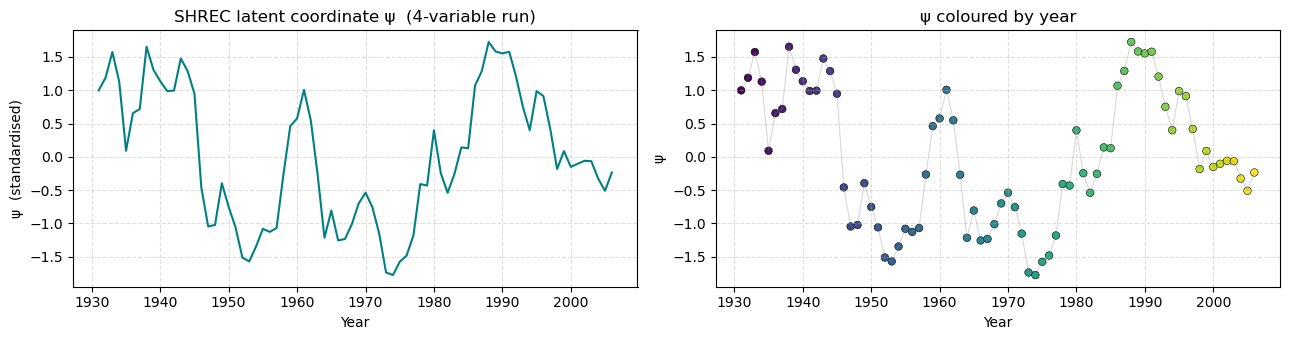

In [8]:
df_psi  = pd.read_csv('shrec_1var_latent_coordinates.csv')
psi_1   = df_psi['Psi_1_Standardized'].values   # already z-scored
years_shrec = df_psi['Year'].values

print(f"ψ₁ loaded: {len(psi_1)} time points ({years_shrec[0]}–{years_shrec[-1]})")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

axes[0].plot(years_shrec, psi_1, color='teal', lw=1.5)
axes[0].set(xlabel='Year', ylabel='ψ  (standardised)',
            title='SHREC latent coordinate ψ  (4-variable run)')
axes[0].grid(ls='--', alpha=0.4)

axes[1].scatter(years_shrec, psi_1, c=years_shrec, cmap='viridis',
                s=30, edgecolors='k', lw=0.4)
axes[1].plot(years_shrec, psi_1, color='gray', alpha=0.3, lw=0.8)
axes[1].set(xlabel='Year', ylabel='ψ', title='ψ coloured by year')
axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

-
## SINDy Residuals

SINDy (`02_SINDy_Initial_Model.ipynb`) discovered the following one-step equations on z-scored variables:

| Variable | Equation |
|----------|-----------|
| a(t+1)   | −0.44 a(t) + 0.60 sin(s(t)) |
| s(t+1)   | −0.50 − 0.49 a(t)·s(t) + 0.65 cos(s(t)) |

The sardine residual is defined as  
$$\epsilon_s(t) = s(t+1) - \hat{s}_{\text{SINDy}}(t+1)$$

**Temporal alignment.**  Raw series have length N = 78 (1929–2006).  SINDy residuals use index pairs (t, t+1) and therefore span years[1:] with length 77.  ψ drops the first E − 1 = 2 points and spans years[2:] with length 76.  The common window is years[2:] (1931–2006, length 76), obtained by discarding the first residual point (year 1930 → 1931 step).


All series aligned to 1931–2006  (N = 76)
SINDy residual  std = 0.9154  (sardine std = 0.9936)


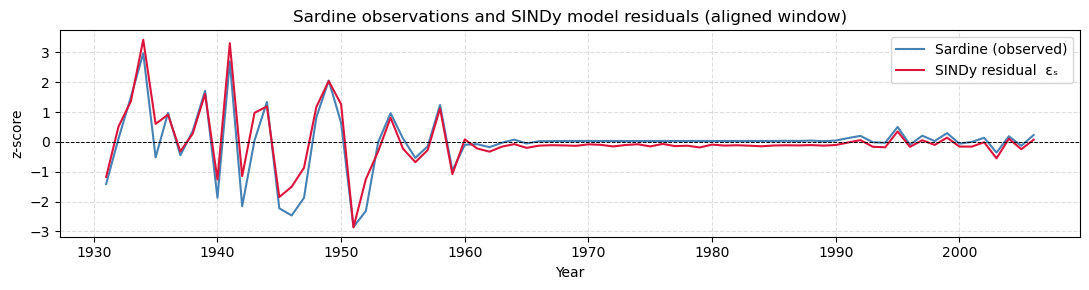

In [9]:
# SINDy one-step predictions (sardine)
a_t = anchovy[:-1]
s_t = sardine[:-1]
sindy_pred_full = -0.50 - 0.49 * a_t * s_t + 0.65 * np.cos(s_t)   # length 77

residuals_full = sardine[1:] - sindy_pred_full   # length 77, covers years[1:]

# Align to ψ₁ window (years[2:], length 76)
E_shrec     = 3
shrec_start = E_shrec - 1   # = 2

sindy_residuals = residuals_full[shrec_start - 1:]   # drop the years[1] point
sardine_aligned = sardine[shrec_start:]
anchovy_aligned = anchovy[shrec_start:]

assert len(sindy_residuals) == len(psi_1), (
    f"Length mismatch: residuals = {len(sindy_residuals)}, ψ₁ = {len(psi_1)}")

print(f"All series aligned to {years_shrec[0]}–{years_shrec[-1]}  (N = {len(psi_1)})")
print(f"SINDy residual  std = {sindy_residuals.std():.4f}  "
      f"(sardine std = {sardine.std():.4f})")

# Sanity-check plot
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(years_shrec, sardine_aligned,  color='steelblue', lw=1.5, label='Sardine (observed)')
ax.plot(years_shrec, sindy_residuals,  color='crimson',   lw=1.5, label='SINDy residual  εₛ')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set(xlabel='Year', ylabel='z-score',
       title='Sardine observations and SINDy model residuals (aligned window)')
ax.legend(); ax.grid(ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## CCM between ψ and Fish Populations

Does the SHREC latent coordinate have a causal relationship with the observed fish populations?  By the CCM convention, a significant and *converging* ρ(L) for direction "X xmap Y" means X's shadow manifold can reconstruct Y — evidence that Y causally influences X.

In [10]:
E_ccm, tau_ccm = 3, 1

L_step1 = safe_L_range(
    [psi_1, sardine_aligned, anchovy_aligned], E_ccm, tau_ccm)
print(f"Step 1  —  L_range: {L_step1[0]}–{L_step1[-1]}  ({len(L_step1)} values)")
print("Running 4 CCM directions …")

L1, rho_sard_xmap_psi1 = ccm_smooth(sardine_aligned, psi_1, E_ccm, tau_ccm, L_step1)
_,  rho_psi1_xmap_sard = ccm_smooth(psi_1, sardine_aligned, E_ccm, tau_ccm, L_step1)
_,  rho_anch_xmap_psi1 = ccm_smooth(anchovy_aligned, psi_1, E_ccm, tau_ccm, L_step1)
_,  rho_psi1_xmap_anch = ccm_smooth(psi_1, anchovy_aligned, E_ccm, tau_ccm, L_step1)

print("Done.")

Step 1  —  L_range: 10–72  (32 values)
Running 4 CCM directions …
Done.


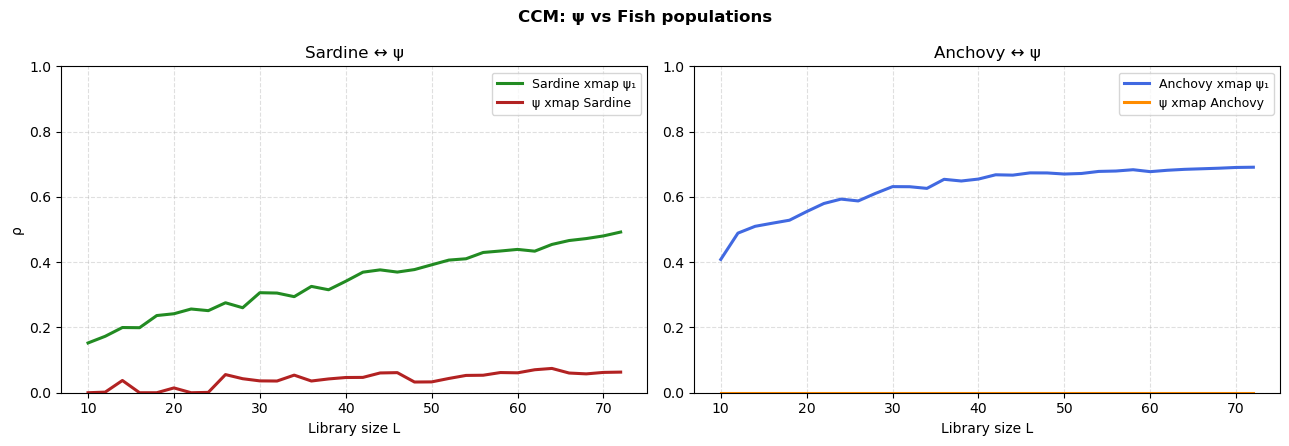

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('CCM: ψ vs Fish populations', fontsize=12, fontweight='bold')

kw = dict(lw=2.2)
axes[0].plot(L1, rho_sard_xmap_psi1, color='forestgreen', **kw, label='Sardine xmap ψ₁')
axes[0].plot(L1, rho_psi1_xmap_sard, color='firebrick',   **kw, label='ψ xmap Sardine')
axes[0].set(title='Sardine ↔ ψ', xlabel='Library size L', ylabel='ρ', ylim=(0, 1))
axes[0].legend(fontsize=9); axes[0].grid(ls='--', alpha=0.4)

axes[1].plot(L1, rho_anch_xmap_psi1, color='royalblue',   **kw, label='Anchovy xmap ψ₁')
axes[1].plot(L1, rho_psi1_xmap_anch, color='darkorange',  **kw, label='ψ xmap Anchovy')
axes[1].set(title='Anchovy ↔ ψ', xlabel='Library size L', ylim=(0, 1))
axes[1].legend(fontsize=9); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## CCM between ψ and SINDy Residuals

Does ψ₁ explain the portion of sardine dynamics that SINDy's equations could not predict?  Converging cross-map skill in either direction would indicate that the latent coordinate encodes dynamical information absent from the sparse model.

Step 2  —  L_range: 10–72  (32 values)
Running 2 CCM directions …
Done.


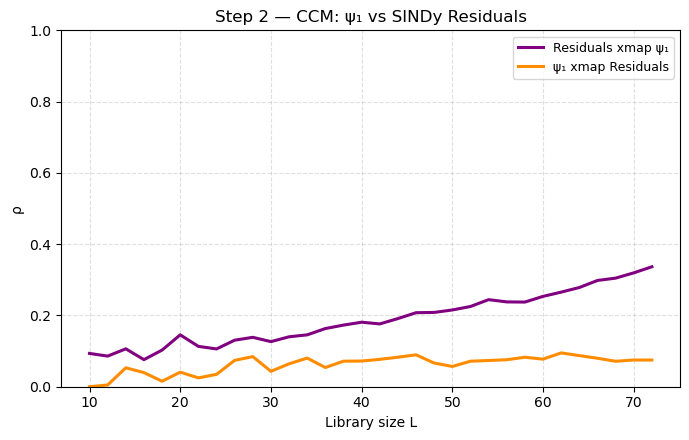

In [14]:
L_step2 = safe_L_range([psi_1, sindy_residuals], E_ccm, tau_ccm)
print(f"Step 2  —  L_range: {L_step2[0]}–{L_step2[-1]}  ({len(L_step2)} values)")
print("Running 2 CCM directions …")

L2, rho_res_xmap_psi1 = ccm_smooth(sindy_residuals, psi_1, E_ccm, tau_ccm, L_step2)
_,  rho_psi1_xmap_res = ccm_smooth(psi_1, sindy_residuals, E_ccm, tau_ccm, L_step2)

print("Done.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(L2, rho_res_xmap_psi1, color='purple',     lw=2.2, label='Residuals xmap ψ₁')
ax.plot(L2, rho_psi1_xmap_res, color='darkorange',  lw=2.2, label='ψ₁ xmap Residuals')
ax.set(title='Step 2 — CCM: ψ₁ vs SINDy Residuals',
       xlabel='Library size L', ylabel='ρ', ylim=(0, 1))
ax.legend(fontsize=9); ax.grid(ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Convergence Analysis

Each CCM curve is fitted to ρ(L) = α · exp(−γL) + ρ∞.  
- **ρ∞ > 0.3 with finite γ** → genuine causal signal that grows with library size.  
- **Flat / γ ≈ 0** → no detectable causal linkage.

CONVERGENCE ANALYSIS — all CCM curves

Sardine ↔ ψ:
  Sardine xmap ψ                                          | ✅  ρ∞ = 0.887   (γ = 0.0095)
  ψ xmap Sardine                                          | ✅  ρ∞ = 0.079   (γ = 0.0274)

Anchovy ↔ ψ:
  Anchovy xmap ψ₁                                         | ✅  ρ∞ = 0.692   (γ = 0.0663)
  ψ xmap Anchovy                                          | ➡  flat / no convergence

Residuals ↔ ψ₁:
  Residuals xmap ψ₁                                       | ✅  ρ∞ = 1.000   (γ = 0.0047)
  ψ xmap Residuals                                        | ✅  ρ∞ = 0.081   (γ = 0.0677)


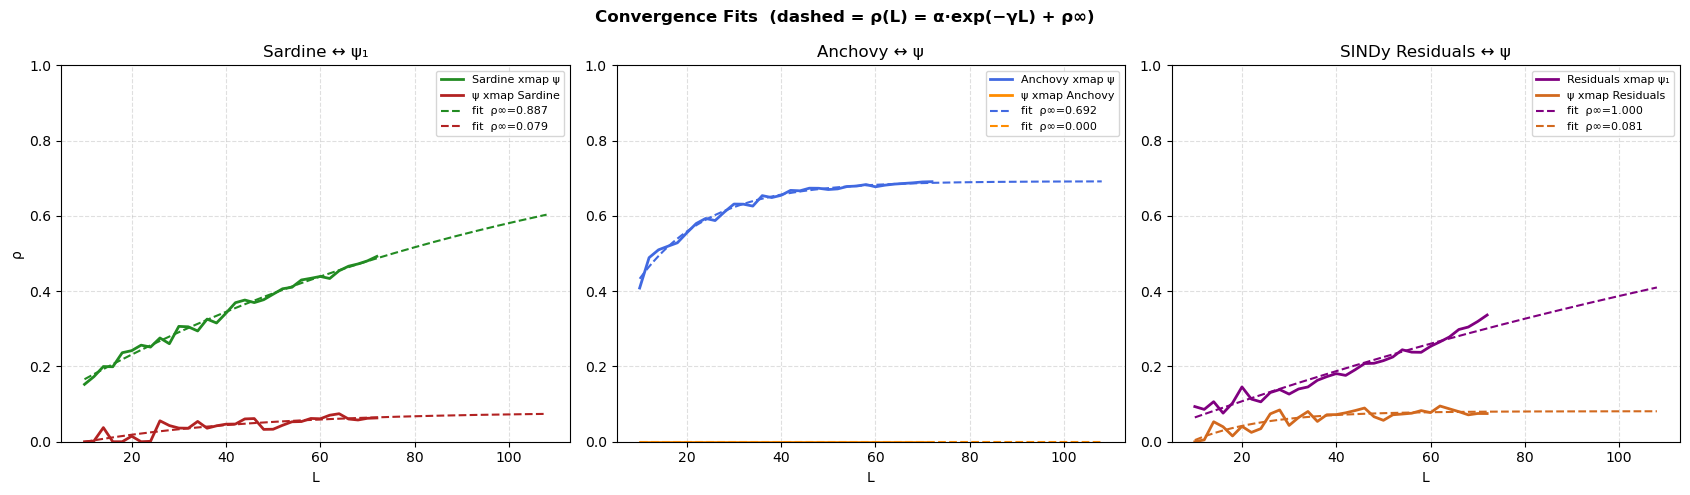


Interpretation guide:
  ρ∞ > 0.3  +  finite γ   →  genuine causal signal
  flat / γ ≈ 0            →  no detectable causal linkage


In [15]:
print("=" * 70)
print("CONVERGENCE ANALYSIS — all CCM curves")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Convergence Fits  (dashed = ρ(L) = α·exp(−γL) + ρ∞)',
             fontsize=12, fontweight='bold')

# Panel 1 — Sardine ↔ ψ₁
print("\nSardine ↔ ψ:")
ax = axes[0]
ax.plot(L1, rho_sard_xmap_psi1, color='forestgreen', lw=2, label='Sardine xmap ψ')
ax.plot(L1, rho_psi1_xmap_sard, color='firebrick',   lw=2, label='ψ xmap Sardine')
fit_convergence(L1, rho_sard_xmap_psi1, 'Sardine xmap ψ', ax, 'forestgreen')
fit_convergence(L1, rho_psi1_xmap_sard, 'ψ xmap Sardine', ax, 'firebrick')
ax.set(title='Sardine ↔ ψ₁', xlabel='L', ylabel='ρ', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

# Panel 2 — Anchovy ↔ ψ
print("\nAnchovy ↔ ψ:")
ax = axes[1]
ax.plot(L1, rho_anch_xmap_psi1, color='royalblue',  lw=2, label='Anchovy xmap ψ')
ax.plot(L1, rho_psi1_xmap_anch, color='darkorange', lw=2, label='ψ xmap Anchovy')
fit_convergence(L1, rho_anch_xmap_psi1, 'Anchovy xmap ψ₁', ax, 'royalblue')
fit_convergence(L1, rho_psi1_xmap_anch, 'ψ xmap Anchovy', ax, 'darkorange')
ax.set(title='Anchovy ↔ ψ', xlabel='L', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

# Panel 3 — Residuals ↔ ψ₁
print("\nResiduals ↔ ψ₁:")
ax = axes[2]
ax.plot(L2, rho_res_xmap_psi1, color='purple',    lw=2, label='Residuals xmap ψ₁')
ax.plot(L2, rho_psi1_xmap_res, color='chocolate', lw=2, label='ψ xmap Residuals')
fit_convergence(L2, rho_res_xmap_psi1, 'Residuals xmap ψ₁', ax, 'purple')
fit_convergence(L2, rho_psi1_xmap_res, 'ψ xmap Residuals', ax, 'chocolate')
ax.set(title='SINDy Residuals ↔ ψ', xlabel='L', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

print()
print("Interpretation guide:")
print("  ρ∞ > 0.3  +  finite γ   →  genuine causal signal")
print("  flat / γ ≈ 0            →  no detectable causal linkage")